In [1]:
import sys, os
import joblib
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt 

%matplotlib inline

In [2]:
DATA_DIR = "../input/jane-street-market-prediction"

In [3]:
train_features_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))

In [4]:
# initial data preprocessing
train_features_df.fillna(-999, inplace=True)
train_features_df.drop(train_features_df[train_features_df['weight'] == 0].index, inplace=True)
# set the action variable based on resp
train_features_df['action'] = (train_features_df['resp'] > 0).astype('int')

In [5]:
train_features = np.array([c for c in train_features_df if 'feature' in c])

In [6]:
# get the X and y arrays
X = train_features_df.values[:, 7:-2]
y = train_features_df.values[:, -1]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.05,
    random_state=2020,
    stratify=y
)

In [8]:
# create a RandomForestClassifier
clf = RandomForestClassifier(
    criterion='gini',
    n_estimators=100,
    random_state=2020,
    n_jobs=-1
)

In [9]:
# clf.fit(X_train, y_train)
clf = joblib.load('../input/jsmp-random-forest/random_forest.bin')

/opt/conda/lib/python3.7/site-packages/sklearn/utils/deprecation.py:143: FutureWarning: The sklearn.ensemble.forest module is  deprecated in version 0.22 and will be removed in version 0.24. The corresponding classes / functions should instead be imported from sklearn.ensemble. Anything that cannot be imported from sklearn.ensemble is now part of the private API.
  warnings.warn(message, FutureWarning)
/opt/conda/lib/python3.7/site-packages/sklearn/utils/deprecation.py:143: FutureWarning: The sklearn.tree.tree module is  deprecated in version 0.22 and will be removed in version 0.24. The corresponding classes / functions should instead be imported from sklearn.tree. Anything that cannot be imported from sklearn.tree is now part of the private API.
  warnings.warn(message, FutureWarning)
/opt/conda/lib/python3.7/site-packages/sklearn/base.py:334: UserWarning: Trying to unpickle estimator DecisionTreeClassifier from version 0.20.3 when using version 0.23.2. This might lead to breaking co

In [10]:
# get the feature importances (returns importance value for each indices)
feature_importances = clf.feature_importances_

In [11]:
feature_imp_idx = np.argsort(feature_importances)[::-1]

In [12]:
# print the top k features
k = 20
for i in range(k):
    print(f"{train_features[feature_imp_idx[i]]}\t {feature_importances[feature_imp_idx[i]]}")

feature_44	 0.011352844395269844
feature_45	 0.011032999383009428
feature_6	 0.010469515837306096
feature_41	 0.010458767541624258
feature_5	 0.010391225971858686
feature_43	 0.01030922837407708
feature_62	 0.010176813173592677
feature_83	 0.010161690813530794
feature_63	 0.010129994456391688
feature_77	 0.009960956044566515
feature_61	 0.009934174975955395
feature_60	 0.009930276714589984
feature_42	 0.009473146919836863
feature_4	 0.009461111328856792
feature_55	 0.009388466141892182
feature_3	 0.009362289648927428
feature_40	 0.009310527971968947
feature_39	 0.009231066158725858
feature_57	 0.00920005457595143
feature_121	 0.009173755767294987


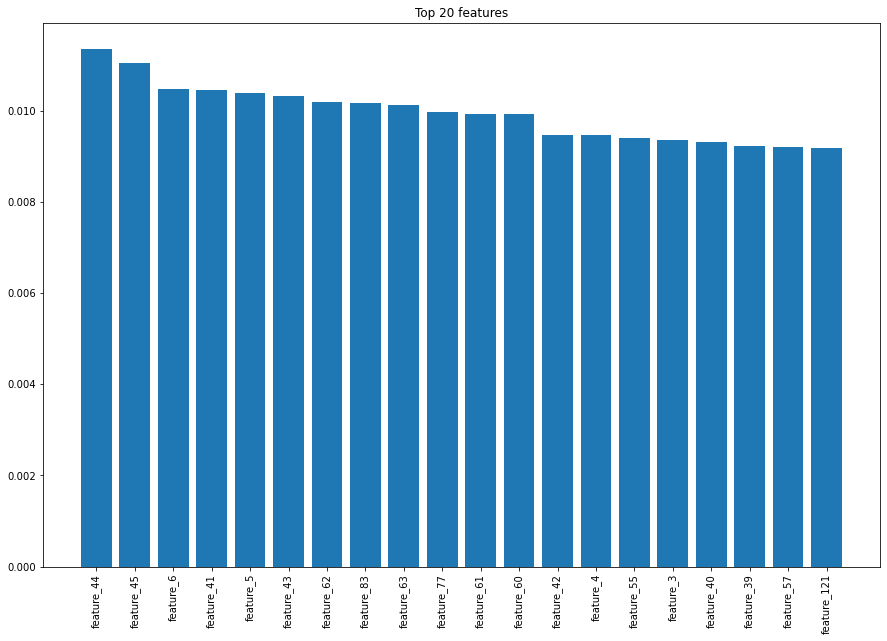

In [13]:
# plot the top k features
plt.figure(figsize=(15, 10))
plt.title(f"Top {k} features")
plt.bar(train_features[feature_imp_idx][:k], feature_importances[feature_imp_idx][:k])
plt.xticks(rotation=90)
plt.show()